**MLP Regressor**

In [ ]:
# # multi layer perceptron
# MLP Regressor implements a multi-layer perceptron (mlp) that trains using backpropagation with no activation function in the output layer.clear_output.

# Therefore , it uses the square error as the loss function , and the output is a set of continuous values 

In [2]:
import pandas as ps
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sklearn
from sklearn import datasets
# Basic libraries for data manipulation and visualization


In [3]:
# Import the libraries for performing classification
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_validate



In [4]:
np.random.seed(306)
cv=ShuffleSplit(n_splits=5,test_size=0.2,random_state=306)


In [5]:
# load dataset
# here we using the california housing price to demo the MLP regressor
dataset=sklearn.datasets.fetch_california_housing()
X,y=dataset.data,dataset.target
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)



In [6]:
X_train.shape,X_test.shape

((16512, 8), (4128, 8))

In [7]:
# fitting the pipeline to implement the MLP Regressor on California housing dataset

#  Let us train a MLP Regressor with three hidden layers each with 32 neurans
pipe=Pipeline([
  ('scaler',StandardScaler()),
  ('mlp_reg',MLPRegressor(hidden_layer_sizes=(32)))
])

In [8]:
cv_results=cross_validate(pipe,
                        X_train,y_train,
                        cv=cv,
                        scoring='neg_mean_absolute_error',
                        return_train_score=True,
                        return_estimator=True,
                        n_jobs=2
                        )

mlp_train_error=-1*cv_results['train_score']
mlp_test_error=-1*cv_results['test_score']
print(f"Average training error: {mlp_train_error.mean():.4f}")
print(f"Average test error: {mlp_test_error.mean():.4f}")
print(f"Standard deviation of test error: {mlp_test_error.std():.4f}")
print(f"Best estimator: {cv_results['estimator'][np.argmin(mlp_test_error)]}")
# cross validate  
#here it is taking time 

Average training error: 0.3810
Average test error: 0.3897
Standard deviation of test error: 0.0063
Best estimator: Pipeline(steps=[('scaler', StandardScaler()),
                ('mlp_reg', MLPRegressor(hidden_layer_sizes=32))])


In [ ]:
pipe.fit(X_train,y_train)
# now training the model on  train dataset and evaluating the model on test dataset
# MLP Regressor parameters default values are used here

,steps,"[('scaler', ...), ('mlp_reg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,loss,'squared_error'
,hidden_layer_sizes,32
,activation,'relu'
,solver,'adam'


In [10]:
mean_absolute_percentage_error(y_test,pipe.predict(X_test))
# evaluating the model on test dataset using mean absolute percentage error

0.2168016418688319

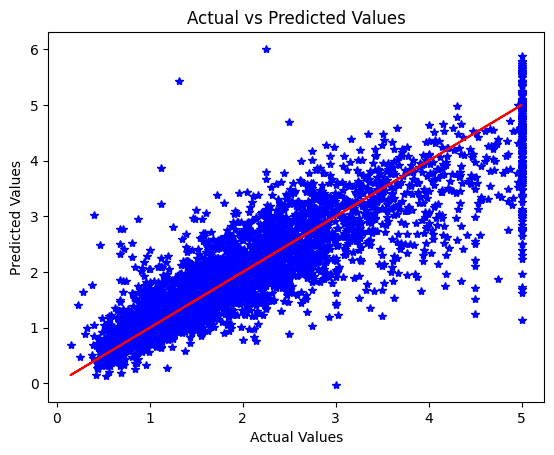

In [13]:
plt.plot(y_test,pipe.predict(X_test),'b*')
plt.plot(y_test,y_test,'r-')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.show()  

In [14]:
# # Using GridSearchCV 
# # let us use grid search cross-validation to explore combinations of parameters of MLP Classifier
# 1.Learnning rate strategies
# 2.Alpha

param_grid={
    'mlp_reg__hidden_layer_sizes':[(32,),(64,),(32,32),(64,64)],
    'mlp_reg__learning_rate':['constant','invscaling','adaptive'],
    'mlp_reg__alpha':[0.0001,0.001,0.01]
}
grid_search=GridSearchCV(pipe,param_grid,cv=cv,scoring='neg_mean_absolute_error',n_jobs=2)
grid_search.fit(X_train,y_train)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {-grid_search.best_score_:.4f}") 
best_mlp_regressor=grid_search.best_estimator_
mean_absolute_percentage_error(y_test,best_mlp_regressor.predict(X_test))
# in training the data using gridsearchcv it is taking time to train the model and evaluate the model on test dataset using mean absolute percentage error

Best parameters: {'mlp_reg__alpha': 0.001, 'mlp_reg__hidden_layer_sizes': (64, 64), 'mlp_reg__learning_rate': 'constant'}
Best cross-validation score: 0.3518


c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


0.18789304933609755

In [ ]:
best_mlp_regressor , mean_absolute_error
